# 02 -- Collision Type (C): Tối ưu Stage 2 (What)

Notebook này chỉ tập trung cải thiện điểm **C** (top-1 accuracy loại va chạm). `core` đã cung cấp baseline `classify_type_cascade` hiện tại.

**Quy tắc khi làm việc ở đây:** chỉ định nghĩa hàm phân loại MỚI, không sửa `classify_type_cascade` gốc trong core. So sánh accuracy mới với `eval_core['C'].mean()`.

Phần dưới đây là toàn bộ chuỗi điều tra bias đã thực hiện: content-free prior, crop+zoom, trajectory-first prompt, describe-then-classify, bearing-in-degrees. **Đọc kỹ trước khi thử hướng mới** -- kết luận hiện tại (xem cell cuối, bearing+code) là bias nằm ở chính bước 'chọn 1 trong N nhãn/giá trị neo rời rạc' của VLM, không phải ở cách diễn đạt câu hỏi hay ở kênh thị giác (đã xác nhận kênh thị giác hoạt động tốt qua phép thử grounding/freeform ở giữa chuỗi này).

In [ ]:
# [SETUP] Tu dong lay core pipeline tu GitHub repo -- khong can mount repo thu cong,
# chay duoc ngay tren Kaggle/Colab (session moi, chua co gi tren may) LAN local co
# san repo (khong clone lai, tu tim thu muc goc).
import os, sys, subprocess

REPO_URL  = 'https://github.com/HoangDinhBui/zero-shot-cctv-accident.git'
REPO_NAME = 'zero-shot-cctv-accident'

def _find_or_clone_repo_root():
    cwd = os.getcwd()
    # Da dang chay tu trong repo (notebook nay o notebooks/, core/ o thu muc cha)
    for base in (cwd, os.path.dirname(cwd)):
        if os.path.exists(os.path.join(base, 'core', 'shared_pipeline.ipynb')):
            return os.path.abspath(base)
    # Chua co -- clone ve thu muc hien tai (Kaggle/Colab session moi)
    if not os.path.exists(REPO_NAME):
        print(f'[SETUP] Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', '--depth', '1', '-q', REPO_URL], check=True)
    return os.path.abspath(REPO_NAME)

REPO_ROOT = _find_or_clone_repo_root()
sys.path.append(os.path.join(REPO_ROOT, 'core'))
print(f'[SETUP] REPO_ROOT = {REPO_ROOT}')

CORE_NB_PATH = os.path.join(REPO_ROOT, 'core', 'shared_pipeline.ipynb')
print(f'[SETUP] Loading core pipeline: {CORE_NB_PATH}')

In [ ]:
# Nap toan bo core (data, model loading, 3-stage baseline, eval, diverse_videos).
# Cac cell pip-install / fix NVRTC / load Qwen3-VL da nam san trong core, se tu
# chay khi %run toi do -- khong can them cell cai thu vien rieng o day.
%run {CORE_NB_PATH}

## 17. Calibrate Before Use (Zhao et al. ICML 2021) -- xap xi bang tan suat thuc nghiem

`classify_type_cascade` da co 3-vote self-consistency (stage1 + motion + geometry)
nhung ca 3 deu tu CUNG 1 model -- neu model co thien kien chung (luon nghieng
t-bone), vote da so KHONG triet tieu duoc bias do (3 mau tuong quan, khong doc
lap). Calibrate Before Use do bias bang cach cho model xem input RONG (khong co
thong tin that), sample nhieu lan, xem no tu nhien nghieng ve nhan nao -- roi
CHIA NGUOC bias do khoi vote that, thay vi tin thang vao vote tho.

Xap xi (khong dung logprob/teacher-forcing that vi rui ro cao voi kien truc
Qwen3-VL cu the) -- dung tan suat thuc nghiem qua N lan sample o temperature>0
tren anh xam trung tinh, dung lam uoc luong bias. Do 1 lan, dung lai cho moi
video (khong do lai moi lan, ton thoi gian vo ich).

In [72]:
# [DIAG] Do content-free prior (Calibrate Before Use, v2 -- content KHONG nhan,
# khong phai anh xam). Anh xam khong kich hoat duoc co che thi giac gay thien
# kien tren video that (da kiem chung: model nghieng "single" 0.84 tren anh xam,
# nhung nghieng "t-bone" tren video that) -- nen ta doi sang khung hinh GIAO THONG
# THAT nhung lay o dau video, TRUOC khi co va cham vai giay. Van la "content-free"
# dung nghia: co xe co that de kich hoat dung co che, nhung khong co va cham that
# de model hoc theo.
import numpy as _np

def vlm_generate_sampled(prompt_text, images, max_new_tokens=32, temperature=0.7):
    """Nhu vlm_generate nhung do_sample=True -- can cho viec do phan bo qua nhieu
    lan goi (greedy se luon ra cung 1 nhan, khong do duoc phan bo)."""
    if not VLM_AVAILABLE:
        return ''
    content = [{'type': 'image', 'image': im} for im in images]
    content.append({'type': 'text', 'text': prompt_text})
    inputs = vlm_processor.apply_chat_template(
        [{'role': 'user', 'content': content}], tokenize=True,
        add_generation_prompt=True, return_dict=True, return_tensors='pt',
    ).to(vlm_model.device)
    with torch.no_grad():
        out = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=True, temperature=temperature, top_p=0.95)
    text = vlm_processor.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    del inputs, out
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return text


def make_precollision_frames(video_path, accident_time, n=6, max_side=336, margin=3.0):
    """Khung hinh THAT truoc va cham >= margin giay -- co xe co that (kich hoat
    dung co che thi giac) nhung khong co va cham that (khong co gi de 'hoc theo').
    Neu accident_time qua som (khong du margin giay truoc do), lay tu t=0."""
    t_end = max(0.5, accident_time - margin)
    t_start = max(0.0, t_end - 2.0)
    frames = sample_frames_stamped(video_path, target_fps=3.0, t_start=t_start,
                                   t_end=t_end, limit=n, max_side=max_side, burn=False)
    return [im for _, im in frames]


def measure_content_free_prior(n_samples=20, temperature=0.7, margin=3.0, seed=SEED):
    """Do tan suat thuc nghiem model chon moi nhan tren khung hinh giao thong THAT
    nhung truoc va cham (khong phai anh xam) -- goi ca 3 loai prompt tren cac video
    RIENG (khac 20 video trong diverse_videos/calibration set, tranh ro ri du lieu
    calibration vao chinh phep do dung de hieu chinh no). Tra ve dict label -> xac
    suat (Laplace-smoothed de tranh chia cho 0 sau nay)."""
    calib_paths = {str(vp) for vp in diverse_videos}
    pool = labels_clean[~labels_clean['abs_video_path'].isin(calib_paths)]
    probe_rows = pool.sample(min(n_samples, len(pool)), random_state=seed).reset_index(drop=True)

    counts = Counter({lbl: 0 for lbl in COLLISION_TYPES})
    prompts_to_probe = list(CLASSIFICATION_PROMPTS.values())

    for i, row in probe_rows.iterrows():
        vp = pathlib.Path(row['abs_video_path'])
        frames = make_precollision_frames(vp, row['accident_time'], margin=margin)
        if not frames:
            continue
        prompt = prompts_to_probe[i % len(prompts_to_probe)]
        label = _parse_type_label(vlm_generate_sampled(prompt, frames, 16, temperature))
        if label is not None:
            counts[label] += 1
        if (i + 1) % 5 == 0:
            print(f'[STATUS] content-free (pre-collision) sample {i+1}/{len(probe_rows)}: {dict(counts)}')

    total = sum(counts.values()) + len(COLLISION_TYPES)   # +1 Laplace moi nhan
    prior = {lbl: (counts[lbl] + 1) / total for lbl in COLLISION_TYPES}
    return prior


print('[STATUS] Do content-free prior tren khung hinh THAT truoc va cham '
      '(~20 video khac tap calibration, mat vai phut)...')
CONTENT_FREE_PRIOR = measure_content_free_prior(n_samples=20, temperature=0.7, margin=3.0)
print(f'\n[VERDICT] Content-free prior (model nghieng nhan nao khi thay xe co that '
      f'nhung CHUA co va cham):')
for lbl, p in sorted(CONTENT_FREE_PRIOR.items(), key=lambda kv: -kv[1]):
    print(f'  {lbl:12s}: {p:.3f}')
print(f'\nNeu 1 nhan (vi du t-bone) chiem ty le cao han han 1/5=0.20 ngay ca khi')
print(f'CHUA co va cham -- xac nhan thien kien he thong that su, dung de hieu chinh voi.')

[STATUS] Do content-free prior tren khung hinh THAT truoc va cham (~20 video khac tap calibration, mat vai phut)...
[STATUS] content-free (pre-collision) sample 5/20: {'head-on': 0, 'rear-end': 0, 'sideswipe': 2, 'single': 1, 't-bone': 2}
[STATUS] content-free (pre-collision) sample 10/20: {'head-on': 0, 'rear-end': 1, 'sideswipe': 3, 'single': 2, 't-bone': 4}
[STATUS] content-free (pre-collision) sample 15/20: {'head-on': 0, 'rear-end': 1, 'sideswipe': 3, 'single': 3, 't-bone': 8}
[STATUS] content-free (pre-collision) sample 20/20: {'head-on': 0, 'rear-end': 1, 'sideswipe': 5, 'single': 3, 't-bone': 11}

[VERDICT] Content-free prior (model nghieng nhan nao khi thay xe co that nhung CHUA co va cham):
  t-bone      : 0.480
  sideswipe   : 0.240
  single      : 0.160
  rear-end    : 0.080
  head-on     : 0.040

Neu 1 nhan (vi du t-bone) chiem ty le cao han han 1/5=0.20 ngay ca khi
CHUA co va cham -- xac nhan thien kien he thong that su, dung de hieu chinh voi.


## 18. classify_type_cascade da hieu chinh bias -- test truoc khi thay pipeline chinh

Giu nguyen 3 vote da co (stage1 + motion + geometry). Thay vi lay dung so (mode),
CHIA so dem moi nhan cho CONTENT_FREE_PRIOR truoc khi chon -- nhan hiem gap
(nhu head-on/single) duoc "nang" len tuong ung voi viec model von it nghieng ve
no; nhan model von thien vi (t-bone) bi "ha" xuong. Test tren 20 video calibration
truoc khi ghi de vao run_inference_vlm that su.

In [73]:
# [DIAG] Luu lai chinh cac khung hinh model dang nhin (cua so quanh t_final, video
# head-on) ra file anh, de kiem tra BANG MAT xem gia thuyet "goc quay CCTV khien
# head-on trong hinh hoc giong t-bone/sideswipe" co dung khong.

OUT_DIR = pathlib.Path('/kaggle/working/head_on_frame_check')
OUT_DIR.mkdir(parents=True, exist_ok=True)

head_on_rows = diverse_labels_df[diverse_labels_df['type'] == 'head-on']

for _, row in head_on_rows.iterrows():
    vp = pathlib.Path(row['abs_video_path'])
    sub_path = 'videos/' + vp.name
    scene = SCENE_BY_PATH.get(sub_path)
    cap = cv2.VideoCapture(str(vp))
    fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = (n / fps) if fps > 0 else 20.0

    hint = SCENE_TYPE_HINTS.get(scene or '', '')
    frames_full = sample_frames_stamped(vp, VLM_CFG['whole_fps'], limit=VLM_CFG['whole_limit'],
                                        max_side=VLM_CFG['image_max_side'], burn=True)
    stage1_json = _extract_json(vlm_generate(build_stage1_prompt(duration, hint),
                                              [im for _, im in frames_full]))
    pred = normalize_prediction(stage1_json, duration)
    t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration)

    frames_win = sample_frames_stamped(vp, 14 / 7.0, t_final - 6.0, t_final + 1.0,
                                       limit=14, max_side=VLM_CFG['image_max_side'], burn=True)

    # Luu PNG thay vi JPEG -- moi truong Kaggle nay bi loi encoder JPEG cua Pillow
    # (lech version voi libjpeg he thong, loi "function takes at most 16 arguments
    # (17 given)"), PNG dung encoder khac nen tranh duoc loi nay.
    stem = vp.stem
    for t, im in frames_win:
        im.convert('RGB').save(OUT_DIR / f'{stem}__t{t:.2f}s.png')

    print(f'[STATUS] {vp.name}: luu {len(frames_win)} frame vao {OUT_DIR}/  '
          f'(t_final={t_final:.2f}s, gt_time={row["accident_time"]:.2f}s)')

print(f'\n[STATUS] Toan bo anh o {OUT_DIR} -- mo tab Output ben phai de xem,')
print('hoac display() tung file ngay trong notebook (cell tiep theo).')

[STATUS] Town03_head-on_wet_48.mp4: luu 8 frame vao /kaggle/working/head_on_frame_check/  (t_final=2.91s, gt_time=3.50s)
[STATUS] Town06_head-on_wet_06.mp4: luu 14 frame vao /kaggle/working/head_on_frame_check/  (t_final=15.53s, gt_time=17.50s)
[STATUS] Town03_head-on_night_40.mp4: luu 14 frame vao /kaggle/working/head_on_frame_check/  (t_final=15.94s, gt_time=6.45s)
[STATUS] Town06_head-on_wet_01.mp4: luu 14 frame vao /kaggle/working/head_on_frame_check/  (t_final=9.47s, gt_time=7.25s)

[STATUS] Toan bo anh o /kaggle/working/head_on_frame_check -- mo tab Output ben phai de xem,
hoac display() tung file ngay trong notebook (cell tiep theo).


Town06_head-on_wet_01__t7.47s.png


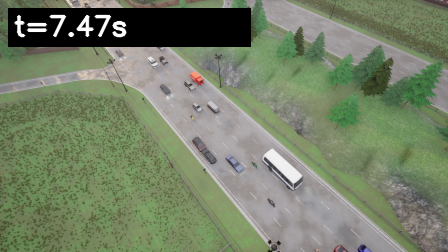

Town06_head-on_wet_01__t7.97s.png


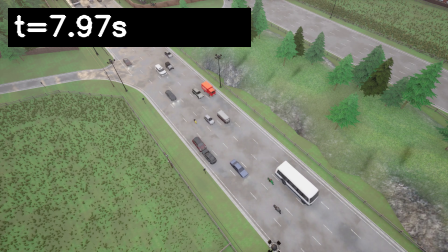

Town06_head-on_wet_01__t8.47s.png


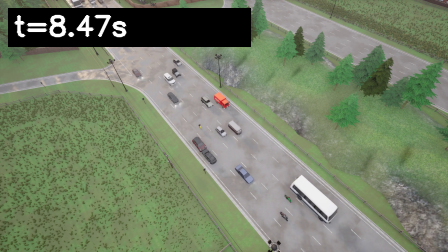

Town06_head-on_wet_01__t8.97s.png


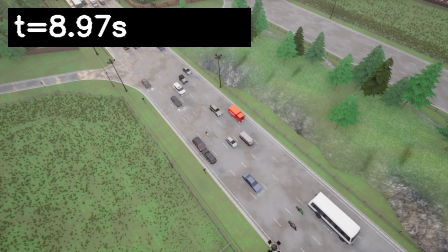

Town06_head-on_wet_01__t9.47s.png


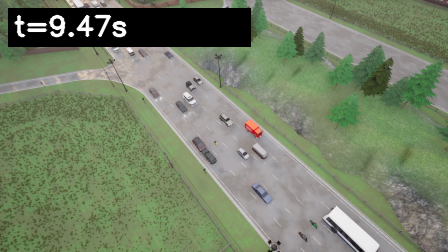

Town06_head-on_wet_01__t9.97s.png


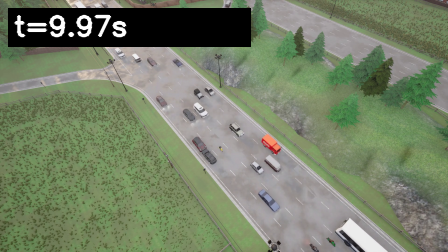

In [74]:
from IPython.display import display
sample_files = sorted(OUT_DIR.glob('Town06_head-on_wet_01*.png'))[-6:]
for f in sample_files:
    print(f.name)
    display(PILImage.open(f))

In [75]:
# [DIAG] Crop + zoom quanh diem va cham TRUOC khi dua vao 3 prompt classification.
# DA SUA: dung stage1 center_x/center_y thay vi stage3_grounding (grounding lech
# trung binh 0.392, co video con bao "khong thay va cham" -- stage1 chi lech 0.149,
# dang tin hon nhieu vi nhin ca clip thay vi 1 frame tinh). crop_frac tang len 0.55
# de chiu duoc sai so localize ~0.15-0.20 ma khong cat mat diem va cham that.

def sample_frames_cropped_zoom(video_path, t_start, t_end, target_fps, limit,
                               center_x, center_y, crop_frac=0.55, out_size=448):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if fps <= 0 or n <= 0:
        cap.release()
        return []
    duration = n / fps
    t0 = max(0.0, t_start)
    t1 = min(duration, t_end)
    if t1 <= t0:
        t1 = min(duration, t0 + 1.0)
    times = np.arange(t0, t1 + 1e-6, 1.0 / max(target_fps, 0.1))
    if len(times) > limit:
        times = times[np.linspace(0, len(times) - 1, limit).round().astype(int)]

    out = []
    for t in times:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(np.clip(round(t * fps), 0, n - 1)))
        ok, frame = cap.read()
        if not ok:
            continue
        h, w = frame.shape[:2]
        side = int(min(h, w) * crop_frac)
        side = max(side, 64)
        cx, cy = int(center_x * w), int(center_y * h)
        x0 = int(np.clip(cx - side // 2, 0, w - side))
        y0 = int(np.clip(cy - side // 2, 0, h - side))
        crop = frame[y0:y0 + side, x0:x0 + side]
        crop = cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_CUBIC)
        out.append((float(t), PILImage.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))))
    cap.release()
    return out


head_on_rows = diverse_labels_df[diverse_labels_df['type'] == 'head-on']
print(f'[STATUS] Test crop+zoom (stage1 center, crop_frac=0.55) tren {len(head_on_rows)} video head-on\n')

crop_results = []

for _, row in head_on_rows.iterrows():
    vp = pathlib.Path(row['abs_video_path'])
    sub_path = 'videos/' + vp.name
    scene = SCENE_BY_PATH.get(sub_path)
    cap = cv2.VideoCapture(str(vp))
    fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = (n / fps) if fps > 0 else 20.0

    hint = SCENE_TYPE_HINTS.get(scene or '', '')
    frames_full = sample_frames_stamped(vp, VLM_CFG['whole_fps'], limit=VLM_CFG['whole_limit'],
                                        max_side=VLM_CFG['image_max_side'], burn=True)
    stage1_json = _extract_json(vlm_generate(build_stage1_prompt(duration, hint),
                                              [im for _, im in frames_full]))
    pred = normalize_prediction(stage1_json, duration)
    t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration)

    cx, cy = pred['center_x'], pred['center_y']
    pt_source = 'stage1_center'

    print('=' * 90)
    print(f'[VIDEO] {vp.name}  t_final={t_final:.2f}s  crop_center=({cx:.2f},{cy:.2f}) '
          f'nguon={pt_source}')
    print('=' * 90)

    frames_full_win = sample_frames_stamped(vp, 6 / 7.0, t_final - 6.0, t_final + 1.0,
                                            limit=6, max_side=VLM_CFG['image_max_side'],
                                            burn=False)
    frames_crop = sample_frames_cropped_zoom(vp, t_final - 6.0, t_final + 1.0,
                                             target_fps=6 / 7.0, limit=6,
                                             center_x=cx, center_y=cy,
                                             crop_frac=0.55, out_size=448)

    for cfg_name, frames_win in [('full-frame (cu)', frames_full_win),
                                  ('crop+zoom v2 (stage1, 0.55)', frames_crop)]:
        votes = []
        for name, prompt in CLASSIFICATION_PROMPTS.items():
            raw = vlm_generate_oom_safe(prompt, frames_win, 32, min_frames=2)
            label = _parse_type_label(raw)
            if label is not None:
                votes.append(label)
        got_headon = 'head-on' in votes
        print(f"  [{cfg_name}] n_frames={len(frames_win)}  votes={votes}  "
              f"head-on_xuat_hien={got_headon}")
        crop_results.append({'video': vp.name, 'config': cfg_name, 'votes': votes,
                             'got_headon': got_headon})

crop_df = pd.DataFrame(crop_results)
print('\n' + '=' * 90)
print('[VERDICT] Ty le head-on xuat hien it nhat 1/3 vote, full-frame vs crop+zoom v2:')
print(crop_df.groupby('config')['got_headon'].mean())

[STATUS] Test crop+zoom (stage1 center, crop_frac=0.55) tren 4 video head-on

[VIDEO] Town03_head-on_wet_48.mp4  t_final=2.91s  crop_center=(0.50,0.43) nguon=stage1_center
  [full-frame (cu)] n_frames=4  votes=['t-bone', 't-bone', 'sideswipe']  head-on_xuat_hien=False
  [crop+zoom v2 (stage1, 0.55)] n_frames=4  votes=['t-bone', 't-bone', 't-bone']  head-on_xuat_hien=False
[VIDEO] Town06_head-on_wet_06.mp4  t_final=15.53s  crop_center=(0.73,0.33) nguon=stage1_center
  [full-frame (cu)] n_frames=6  votes=['sideswipe', 'sideswipe', 'sideswipe']  head-on_xuat_hien=False
  [crop+zoom v2 (stage1, 0.55)] n_frames=6  votes=['t-bone', 't-bone', 't-bone']  head-on_xuat_hien=False
[VIDEO] Town03_head-on_night_40.mp4  t_final=15.94s  crop_center=(0.50,0.50) nguon=stage1_center
  [full-frame (cu)] n_frames=6  votes=['t-bone', 't-bone', 't-bone']  head-on_xuat_hien=False
  [crop+zoom v2 (stage1, 0.55)] n_frames=6  votes=['t-bone', 't-bone', 't-bone']  head-on_xuat_hien=False
[VIDEO] Town06_head-on_w

In [76]:
# [DIAG] Prompt moi: buoc model mo ta huong di chuyen tung xe TRUOC khi suy ra
# loai va cham, thay vi suy luan truc tiep tu tu the luc cham (cach 3 prompt cu
# trong CLASSIFICATION_PROMPTS deu dang lam). Cua so khung hinh cung keo dai ve
# TRUOC (t_final-4.0) thay vi doi xung, de thay quy dao tiep can chu khong chi
# dong do nat luc cham -- giong tinh than docstring cua extract_frames_window
# (Section 5) nhung ap dung dung cho nhanh classification nay.

TRAJECTORY_PROMPT = (
    "These sequential CCTV frames show a traffic accident, with a WIDER window "
    "BEFORE the moment of impact so you can watch each vehicle approach, not just "
    "the wreckage afterward.\n\n"
    "Step 1 -- count vehicles. How many moving vehicles are directly involved in "
    "the crash? If exactly one, this is 'single' and you can skip to the answer.\n\n"
    "Step 2 -- for EACH vehicle involved, watch it across the frames BEFORE contact "
    "and describe its direction of travel using exactly one of: 'left-to-right', "
    "'right-to-left', 'toward-camera', 'away-from-camera', "
    "'diagonal-upper-left-to-lower-right', 'diagonal-upper-right-to-lower-left', "
    "'diagonal-upper-right-to-lower-left', 'diagonal-lower-left-to-upper-right', "
    "or 'stationary/parked'. Do this from the APPROACH frames, not from the final "
    "collision shape -- do not work backward from the wreckage.\n\n"
    "Step 3 -- apply this rule to the two directions you found:\n"
    "  - same direction, one behind the other -> rear-end\n"
    "  - opposite/facing directions on roughly the same line -> head-on\n"
    "  - directions cross at close to a right angle (e.g. one left-to-right, one "
    "toward-camera/away-from-camera) -> t-bone\n"
    "  - same or near-parallel directions, side-by-side rather than in-line -> sideswipe\n"
    "  - only one vehicle moving -> single\n\n"
    f"Reference definitions: {TYPE_DEFINITIONS}\n\n"
    "Output ONLY this JSON (vehicle_b_direction can be null if single):\n"
    '{"num_vehicles": <1 or 2>, "vehicle_a_direction": "<label from Step 2>", '
    '"vehicle_b_direction": "<label from Step 2 or null>", '
    '"type": "head-on|rear-end|sideswipe|t-bone|single"}'
)


def classify_type_trajectory(video_path: pathlib.Path, t_final: float,
                             type_from_stage1: str) -> tuple:
    """Tra ve (label, raw_json_or_None) -- giu raw de debug huong xe model thay,
    khong chi nhan cuoi cung (diem yeu cua cascade cu: khong biet MODEL DA THAY
    GI, chi biet no doan gi)."""
    if not VLM_AVAILABLE:
        return type_from_stage1, None

    frames = sample_frames_stamped(video_path, 2.0, t_final - 4.0, t_final + 1.0,
                                   limit=8, max_side=VLM_CFG['image_max_side'], burn=False)
    if not frames:
        return type_from_stage1, None

    raw = vlm_generate_oom_safe(TRAJECTORY_PROMPT, frames, 150, min_frames=3)
    parsed = _extract_json(raw)
    if parsed and isinstance(parsed.get('type'), str):
        label = _parse_type_label(parsed['type'])
        if label is not None:
            return label, parsed
    # JSON parse that hoac field 'type' hong -- thu vot nhan tho tu toan bo text
    label = _parse_type_label(raw)
    return (label if label is not None else type_from_stage1), parsed


print('[STATUS] TRAJECTORY_PROMPT / classify_type_trajectory defined')

rows_traj = []
for vp, gt_type in zip(diverse_videos, diverse_labels_df['type']):
    try:
        sub_path = 'videos/' + vp.name
        scene = SCENE_BY_PATH.get(sub_path)
        cap = cv2.VideoCapture(str(vp))
        fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        duration = (n / fps) if fps > 0 else 20.0

        pred = stage1_full_scan(vp, duration, scene)
        t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration)

        type_raw = classify_type_cascade(vp, t_final, pred['type'])
        type_raw = apply_scene_type_postfix(type_raw, scene)

        type_traj, traj_json = classify_type_trajectory(vp, t_final, pred['type'])
        type_traj = apply_scene_type_postfix(type_traj, scene)

        dirs = ''
        if traj_json:
            dirs = f"[A={traj_json.get('vehicle_a_direction')} B={traj_json.get('vehicle_b_direction')}]"

        rows_traj.append({'video': vp.name, 'gt': gt_type, 'pred_raw': type_raw,
                          'pred_traj': type_traj, 'directions': dirs})
        print(f"[STATUS] {vp.name[:35]:35s} gt={gt_type:<10} raw={type_raw:<10} "
              f"traj={type_traj:<10} {dirs}")
    except Exception as e:
        print(f"[ERROR] {vp.name}: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        rows_traj.append({'video': vp.name, 'gt': gt_type, 'pred_raw': None,
                          'pred_traj': None, 'directions': 'ERROR'})

traj_df = pd.DataFrame(rows_traj)
valid = traj_df.dropna(subset=['pred_raw', 'pred_traj'])
acc_raw = (valid['pred_raw'] == valid['gt']).mean()
acc_traj = (valid['pred_traj'] == valid['gt']).mean()
print(f"\n[VERDICT] Accuracy majority-vote cascade (cu) : {acc_raw:.2%}  ({len(valid)} video)")
print(f"          Accuracy trajectory-first (moi)       : {acc_traj:.2%}  ({len(valid)} video)")
print(f"\n[CONFUSION] pred_raw:")
print(valid['pred_raw'].value_counts())
print(f"\n[CONFUSION] pred_traj:")
print(valid['pred_traj'].value_counts())

n_changed = (valid['pred_raw'] != valid['pred_traj']).sum()
n_fixed = ((valid['pred_raw'] != valid['gt']) & (valid['pred_traj'] == valid['gt'])).sum()
n_broke = ((valid['pred_raw'] == valid['gt']) & (valid['pred_traj'] != valid['gt'])).sum()
print(f"\n[STATUS] So video doi ket qua: {n_changed}/{len(valid)}  "
      f"(sua dung: {n_fixed}, lam sai them: {n_broke})")

[STATUS] TRAJECTORY_PROMPT / classify_type_trajectory defined
[STATUS] Town03_head-on_wet_48.mp4           gt=head-on    raw=t-bone     traj=head-on    [A=left-to-right B=right-to-left]
[STATUS] Town06_head-on_wet_06.mp4           gt=head-on    raw=sideswipe  traj=head-on    [A=left-to-right B=right-to-left]
[STATUS] Town03_head-on_night_40.mp4         gt=head-on    raw=t-bone     traj=head-on    [A=toward-camera B=away-from-camera]
[STATUS] Town06_head-on_wet_01.mp4           gt=head-on    raw=sideswipe  traj=head-on    [A=left-to-right B=right-to-left]
[STATUS] Town04_rear-end_sunset_13.mp4       gt=rear-end   raw=t-bone     traj=head-on    [A=left-to-right B=right-to-left]
[STATUS] Town04_rear-end_rain_09.mp4         gt=rear-end   raw=t-bone     traj=t-bone     [A=diagonal-upper-right-to-lower-left B=diagonal-upper-left-to-lower-right]
[STATUS] Town05_rear-end_rain_142.mp4        gt=rear-end   raw=t-bone     traj=head-on    [A=toward-camera B=away-from-camera]
[STATUS] Town07_rear-e

In [77]:
# [DIAG] Neo dung 2 xe va cham bang crop quanh center (stage1), roi hoi GOC SO
# (0-360 do) cho tung xe -- KHONG bao gio hoi model chon nhan categorical nua.
# Phan loai cuoi cung tinh bang code (hieu goc lech + nguong cung), khong qua
# VLM -- de kiem tra bias co nam o chinh buoc "chon 1 trong 5 nhan" hay khong.

BEARING_PROMPT = (
    "This cropped CCTV view is zoomed in on a traffic collision between exactly "
    "two vehicles (ignore anything else visible). The frames are in chronological "
    "order, ending at or just after the moment of contact.\n\n"
    "For EACH of the two vehicles, estimate its direction of travel in the frames "
    "BEFORE contact, as a compass bearing in degrees where 0=toward top of frame, "
    "90=toward right edge, 180=toward bottom of frame, 270=toward left edge "
    "(measure the direction it is actually moving, not which way it's facing if parked).\n"
    "If a vehicle is not moving (parked/stationary), set its bearing to null.\n\n"
    "Output ONLY this JSON:\n"
    '{"vehicle_1_bearing_deg": <0-360 or null>, "vehicle_2_bearing_deg": <0-360 or null>, '
    '"vehicle_1_desc": "<3-5 words, color+type>", "vehicle_2_desc": "<3-5 words, color+type>"}'
)


def bearing_to_type(b1, b2) -> str:
    """Phan loai bang CODE, khong qua VLM. b1/b2 la do, hoac None neu dung yen."""
    if b1 is None and b2 is None:
        return None
    if b1 is None or b2 is None:
        return 'single'  # 1 xe dung yen -- coi nhu chi 1 xe thuc su chuyen dong

    diff = abs(b1 - b2) % 360
    diff = min(diff, 360 - diff)  # 0-180, goc lech nho nhat

    if diff <= 30:
        return 'rear-end'        # gan nhu cung huong
    elif diff >= 150:
        return 'head-on'         # gan nhu doi huong
    elif 60 <= diff <= 120:
        return 't-bone'          # gan vuong goc
    else:
        return 'sideswipe'       # lech nhung khong ro ret (30-60 hoac 120-150)


def classify_type_bearing_code(video_path: pathlib.Path, t_final: float,
                               center_x: float, center_y: float,
                               type_from_stage1: str) -> tuple:
    if not VLM_AVAILABLE:
        return type_from_stage1, None

    frames = sample_frames_cropped_zoom(video_path, t_final - 4.0, t_final + 1.0,
                                        target_fps=6/7.0, limit=8,
                                        center_x=center_x, center_y=center_y,
                                        crop_frac=0.6, out_size=448)
    if not frames:
        return type_from_stage1, None

    raw = vlm_generate_oom_safe(BEARING_PROMPT, frames, 150, min_frames=3)
    parsed = _extract_json(raw)
    if not parsed:
        return type_from_stage1, None

    b1, b2 = parsed.get('vehicle_1_bearing_deg'), parsed.get('vehicle_2_bearing_deg')
    label = bearing_to_type(b1, b2)
    return (label if label is not None else type_from_stage1), parsed


print('[STATUS] bearing-in-degrees + code-side classification defined')

rows_bear = []
for vp, gt_type in zip(diverse_videos, diverse_labels_df['type']):
    try:
        sub_path = 'videos/' + vp.name
        scene = SCENE_BY_PATH.get(sub_path)
        cap = cv2.VideoCapture(str(vp))
        fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        duration = (n / fps) if fps > 0 else 20.0

        pred = stage1_full_scan(vp, duration, scene)
        t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration)

        type_raw = apply_scene_type_postfix(classify_type_cascade(vp, t_final, pred['type']), scene)
        type_bear, bj = classify_type_bearing_code(vp, t_final, pred['center_x'],
                                                    pred['center_y'], pred['type'])
        type_bear = apply_scene_type_postfix(type_bear, scene)

        rows_bear.append({'video': vp.name, 'gt': gt_type, 'pred_raw': type_raw,
                          'pred_bear': type_bear, 'bearing_json': bj})
        b1 = bj.get('vehicle_1_bearing_deg') if bj else None
        b2 = bj.get('vehicle_2_bearing_deg') if bj else None
        d1 = bj.get('vehicle_1_desc') if bj else None
        d2 = bj.get('vehicle_2_desc') if bj else None
        print(f"[STATUS] {vp.name[:35]:35s} gt={gt_type:<10} raw={type_raw:<10} "
              f"bear={type_bear:<10} b1={b1}({d1}) b2={b2}({d2})")
    except Exception as e:
        print(f"[ERROR] {vp.name}: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        rows_bear.append({'video': vp.name, 'gt': gt_type, 'pred_raw': None,
                          'pred_bear': None, 'bearing_json': None})

bear_df = pd.DataFrame(rows_bear)
valid = bear_df.dropna(subset=['pred_raw', 'pred_bear'])
acc_raw = (valid['pred_raw'] == valid['gt']).mean()
acc_bear = (valid['pred_bear'] == valid['gt']).mean()
print(f"\n[VERDICT] Accuracy cascade cu           : {acc_raw:.2%}")
print(f"          Accuracy bearing+code (moi)     : {acc_bear:.2%}")
print(f"\n[CONFUSION] pred_bear:")
print(valid['pred_bear'].value_counts())
n_changed = (valid['pred_raw'] != valid['pred_bear']).sum()
n_fixed = ((valid['pred_raw'] != valid['gt']) & (valid['pred_bear'] == valid['gt'])).sum()
n_broke = ((valid['pred_raw'] == valid['gt']) & (valid['pred_bear'] != valid['gt'])).sum()
print(f"\n[STATUS] Doi ket qua: {n_changed}/{len(valid)}  (sua dung: {n_fixed}, sai them: {n_broke})")

[STATUS] bearing-in-degrees + code-side classification defined
[STATUS] Town03_head-on_wet_48.mp4           gt=head-on    raw=t-bone     bear=rear-end   b1=270(red sedan) b2=270(red sedan)
[STATUS] Town06_head-on_wet_06.mp4           gt=head-on    raw=sideswipe  bear=rear-end   b1=180(red fire engine) b2=180(black pickup truck)
[STATUS] Town03_head-on_night_40.mp4         gt=head-on    raw=t-bone     bear=t-bone     b1=270(red car turning left) b2=180(silver car turning right)
[STATUS] Town06_head-on_wet_01.mp4           gt=head-on    raw=sideswipe  bear=rear-end   b1=180(white bus) b2=180(orange van)
[STATUS] Town04_rear-end_sunset_13.mp4       gt=rear-end   raw=t-bone     bear=rear-end   b1=180(black sedan) b2=180(red sedan)
[STATUS] Town04_rear-end_rain_09.mp4         gt=rear-end   raw=t-bone     bear=rear-end   b1=180(orange van) b2=180(dark car)
[STATUS] Town05_rear-end_rain_142.mp4        gt=rear-end   raw=t-bone     bear=t-bone     b1=180(red sedan) b2=270(silver SUV)
[STATUS] T

## Thử nghiệm tiếp theo -- point-based grounding (chưa chạy)

Hướng đang đề xuất: bỏ hẳn việc hỏi VLM ước lượng bất kỳ giá trị rời rạc/neo nào (nhãn, hay độ bearing) -- chỉ hỏi TOẠ ĐỘ ĐIỂM ở 2 mốc thời gian (định dạng giống `GROUNDING_PROMPT` đã có trong core, x/y 0-1000), rồi CODE tự tính vector dịch chuyển + góc bằng `atan2` (đã import `math` ở core). Cell bên dưới là bản đã viết, **chưa chạy/test trên GPU thật** -- chạy và dán kết quả `b1/b2` để xem góc có còn dồn vào vài giá trị cố định hay không.

In [ ]:
# [DIAG] Bo han buoc "uoc luong bearing" (van con neo 4 gia tri 0/90/180/270 trong
# chinh prompt truoc -- nghi la nguyen nhan collapse thay o cell truoc). Thay bang 2
# lan hoi TOA DO DIEM don gian (dinh dang giong GROUNDING_PROMPT co san o core, x,y
# 0-1000) tren 2 frame cach nhau mot khoang thoi gian, roi CODE tu tinh vector dich
# chuyen + goc bang atan2 -- khong con gia tri neo nao trong prompt de model bam vao.

FRAME_POINTS_PROMPT = (
    "This CCTV frame is cropped/zoomed around a traffic collision between exactly "
    "two vehicles (ignore anything else visible, even if partially in frame). "
    "For EACH of the two vehicles, report a short distinguishing description "
    "(color + type, e.g. 'red sedan') and the pixel location of its center as "
    "normalized coordinates: x (0=left edge, 1000=right edge), "
    "y (0=top edge, 1000=bottom edge).\n\n"
    "Output ONLY this JSON:\n"
    '{"vehicles": [{"desc": "<color+type>", "x": <0-1000>, "y": <0-1000>}, '
    '{"desc": "<color+type>", "x": <0-1000>, "y": <0-1000>}]}'
)


def get_frame_points(video_path, t, center_x, center_y, crop_frac=0.6, out_size=448):
    frames = sample_frames_cropped_zoom(video_path, t, t + 0.05, target_fps=20.0,
                                        limit=1, center_x=center_x, center_y=center_y,
                                        crop_frac=crop_frac, out_size=out_size)
    if not frames:
        return None
    raw = vlm_generate_oom_safe(FRAME_POINTS_PROMPT, frames, 150, min_frames=1)
    parsed = _extract_json(raw)
    if not parsed or 'vehicles' not in parsed or len(parsed['vehicles']) < 2:
        return None
    return parsed['vehicles'][:2]


def match_vehicles(early, late):
    """Chi 2 xe -> 2 cach ghep. Chon cach ghep co tong khoang cach nho hon
    (gia dinh xe khong 'nhay' xa trong vai giay)."""
    (e0, e1), (l0, l1) = early, late
    d_straight = ((e0['x']-l0['x'])**2 + (e0['y']-l0['y'])**2) ** 0.5 + \
                 ((e1['x']-l1['x'])**2 + (e1['y']-l1['y'])**2) ** 0.5
    d_swap = ((e0['x']-l1['x'])**2 + (e0['y']-l1['y'])**2) ** 0.5 + \
             ((e1['x']-l0['x'])**2 + (e1['y']-l0['y'])**2) ** 0.5
    return [(e0, l0), (e1, l1)] if d_straight <= d_swap else [(e0, l1), (e1, l0)]


def bearing_from_points(e, l, min_disp_px=25):
    dx, dy = l['x'] - e['x'], l['y'] - e['y']
    if (dx ** 2 + dy ** 2) ** 0.5 < min_disp_px:
        return None
    return math.degrees(math.atan2(dx, -dy)) % 360


def bearing_to_type_v2(b1, b2):
    if b1 is None and b2 is None:
        return None
    if b1 is None or b2 is None:
        return 'single'
    diff = abs(b1 - b2) % 360
    diff = min(diff, 360 - diff)
    if diff <= 30:
        return 'rear-end'
    elif diff >= 150:
        return 'head-on'
    elif 60 <= diff <= 120:
        return 't-bone'
    else:
        return 'sideswipe'


def classify_type_points_code(video_path, t_final, center_x, center_y, type_from_stage1):
    if not VLM_AVAILABLE:
        return type_from_stage1, None
    early = get_frame_points(video_path, t_final - 3.0, center_x, center_y)
    late = get_frame_points(video_path, t_final - 0.3, center_x, center_y)
    if not early or not late:
        return type_from_stage1, None
    (e0, l0), (e1, l1) = match_vehicles(early, late)
    b1 = bearing_from_points(e0, l0)
    b2 = bearing_from_points(e1, l1)
    label = bearing_to_type_v2(b1, b2)
    debug = {'b1': b1, 'b2': b2, 'd1': e0.get('desc'), 'd2': e1.get('desc')}
    return (label if label is not None else type_from_stage1), debug


print('[STATUS] point-based (2-frame grounding) + code-side angle defined')

rows_pts = []
for vp, gt_type in zip(diverse_videos, diverse_labels_df['type']):
    try:
        sub_path = 'videos/' + vp.name
        scene = SCENE_BY_PATH.get(sub_path)
        cap = cv2.VideoCapture(str(vp))
        fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        cap.release()
        duration = (n / fps) if fps > 0 else 20.0

        pred = stage1_full_scan(vp, duration, scene)
        t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration)

        type_raw = apply_scene_type_postfix(classify_type_cascade(vp, t_final, pred['type']), scene)
        type_pts, dbg = classify_type_points_code(vp, t_final, pred['center_x'],
                                                   pred['center_y'], pred['type'])
        type_pts = apply_scene_type_postfix(type_pts, scene)

        rows_pts.append({'video': vp.name, 'gt': gt_type, 'pred_raw': type_raw,
                         'pred_pts': type_pts, 'debug': dbg})
        b1 = dbg.get('b1') if dbg else None
        b2 = dbg.get('b2') if dbg else None
        print(f"[STATUS] {vp.name[:35]:35s} gt={gt_type:<10} raw={type_raw:<10} "
              f"pts={type_pts:<10} b1={b1} b2={b2}")
    except Exception as e:
        print(f"[ERROR] {vp.name}: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        rows_pts.append({'video': vp.name, 'gt': gt_type, 'pred_raw': None,
                         'pred_pts': None, 'debug': None})

pts_df = pd.DataFrame(rows_pts)
valid = pts_df.dropna(subset=['pred_raw', 'pred_pts'])
acc_raw = (valid['pred_raw'] == valid['gt']).mean()
acc_pts = (valid['pred_pts'] == valid['gt']).mean()
print(f"\n[VERDICT] Accuracy cascade cu (core)   : {acc_raw:.2%}")
print(f"          Accuracy point+code (moi)      : {acc_pts:.2%}")
print(valid['pred_pts'].value_counts())

---
# 🔧 KHU VỰC DEV — Collision Type (C)
### Người phụ trách C viết code TỪ ĐÂY XUỐNG DƯỚI. Không sửa gì ở trên (đó là core + lịch sử điều tra bias).
---

**Đọc trước khi viết code mới:** toàn bộ phần trên đã kết luận bias nằm ở việc VLM phải "chọn 1 trong N giá trị neo rời rạc" (nhãn categorical, hoặc số bearing có neo trong prompt) — không phải ở cách diễn đạt câu hỏi hay ở kênh thị giác. Cell `c_points_cell` ngay phía trên (point-based grounding + `atan2` bằng code) là hướng đang thử, **chưa chạy trên GPU thật** — ưu tiên chạy cell đó trước, xem `b1/b2` có còn dồn về vài giá trị cố định không, trước khi thử hướng hoàn toàn mới.

**Việc cần làm:** định nghĩa hàm phân loại MỚI (ví dụ `classify_type_vNEXT`), KHÔNG sửa `classify_type_cascade` gốc import từ `core`.

In [ ]:
# TODO: dinh nghia ham phan loai loai va cham moi cho C o day.
# Vi du khung san (xoa va viet lai theo huong ban chon):
#
# def classify_type_vNEXT(video_path, t_final, type_from_stage1):
#     ...
#     return label   # 'head-on'|'rear-end'|'sideswipe'|'t-bone'|'single'


In [ ]:
# [EVAL] So sanh C moi vs baseline core -- CHAY CELL NAY TRUOC KHI MO PR.
# Doi ten ham trong vong lap ben duoi thanh ham ban vua dinh nghia o tren.

rows_C_new = []
for vp, gt_type in zip(diverse_videos, diverse_labels_df['type']):
    sub_path = 'videos/' + vp.name
    scene = SCENE_BY_PATH.get(sub_path)
    cap = cv2.VideoCapture(str(vp))
    fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = (n / fps) if fps > 0 else 20.0

    pred = stage1_full_scan(vp, duration, scene)                              # giu nguyen (core)
    t_final = stage2_time_refine_numbered(vp, pred['accident_time'], duration) # giu nguyen (core)
    pt = stage3_grounding(vp, t_final)                                        # giu nguyen (core)
    if pt is not None:
        pred['center_x'], pred['center_y'] = pt

    # <-- doi dong duoi day sang ham moi cua ban -->
    pred['type'] = classify_type_cascade(vp, t_final, pred['type'])
    pred['type'] = apply_scene_type_postfix(pred['type'], scene)              # giu nguyen (core)

    rows_C_new.append({'path': str(vp), 'accident_time': t_final,
                       'center_x': pred['center_x'], 'center_y': pred['center_y'],
                       'type': pred['type']})

eval_C_new = score_predictions(pd.DataFrame(rows_C_new), diverse_labels_df)
print(f"[BASELINE] C = {eval_core['C'].mean():.4f}")
print(f"[MOI]      C = {eval_C_new['C'].mean():.4f}")
print(f"[DELTA]        {eval_C_new['C'].mean() - eval_core['C'].mean():+.4f}")